In [1]:
import json
student = {
    "name": "Priya",
    "age": 25,"department":"CSE","semester":5,
    "subject":["AI","Data Mining","DBMS"]}
with open("student.json","w")as file:
    json.dump(student,file,indent=4)


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
path="/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
iris=pd.read_csv(path)
print("shape of the dataset:",iris.shape)
print("\nFirst 5 Rows:")
print(iris.head())

shape of the dataset: (150, 6)

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
X = iris.iloc[:, 1:5]
y = iris["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("\nPredicted Species:")
print(y_pred)

print("\nActual Species:")
print(y_test.values)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Predicted Species:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']

Actual Species:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginic

****1.Write a python program to use bfs and dfs search.****

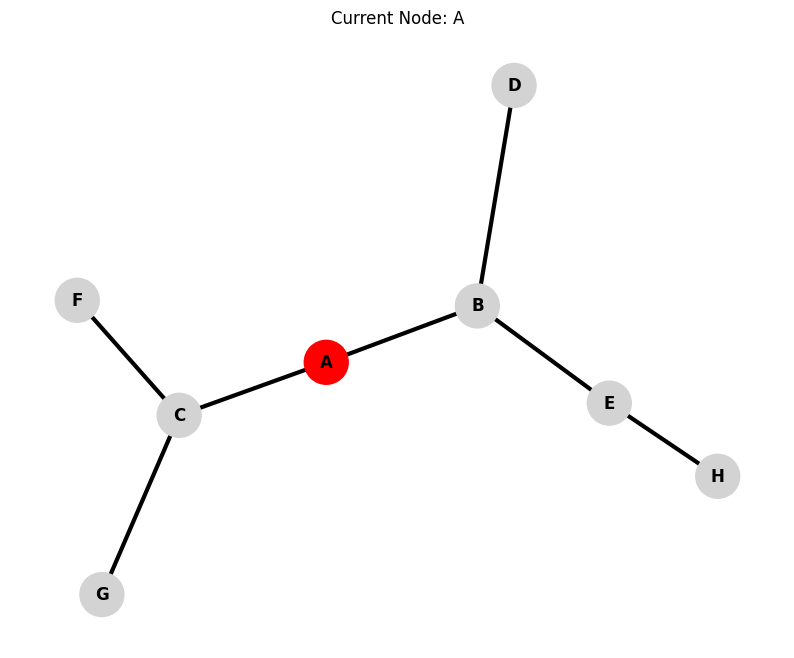

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import deque

# ---------- Graph setup ----------
G = nx.Graph()
edge = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("B", "E"),
    ("C", "F"),
    ("C", "G"),   # <-- was missing a comma here
    ("E", "H")
]
G.add_edges_from(edge)

# ---------- BFS (run fully first, store order + parents) ----------
visited = []
parent = {}
queue = deque(['A'])

while queue:
    node = queue.popleft()
    if node not in visited:
        visited.append(node)
        for neighbour in sorted(G.neighbors(node)):
            if neighbour not in visited:
                parent[neighbour] = node
                queue.append(neighbour)

# ---------- Layout (fixed, computed once) ----------
pos = nx.spring_layout(G, seed=5)   # fixed: seed goes inside spring_layout(), not G

fig, ax = plt.subplots(figsize=(10, 8))

# ---------- Animation update function ----------
def update(frame):
    ax.clear()

    visited_now = set(visited[:frame + 1])   # nodes visited up to this frame

    node_colors = [
        'red' if n in visited_now else 'lightgray'
        for n in G.nodes()
    ]

    edge_colors = []
    for u, v in G.edges():
        if (v in parent and parent[v] == u and v in visited_now) or \
           (u in parent and parent[u] == v and u in visited_now):
            edge_colors.append('green')
        else:
            edge_colors.append('black')

    nx.draw(
        G, pos, ax=ax,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1000,
        width=3,
        font_weight='bold'
    )
    ax.set_title(f"Current Node: {visited[frame]}")

# ---------- Run animation ----------
ani = FuncAnimation(fig, update, frames=len(visited), interval=1000, repeat=False)

from IPython.display import HTML
HTML(ani.to_jshtml())